In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

import datetime
from datetime import date, timedelta

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [ ]:
today = date.today()

d1 = today.strftime("%Y-%m-%d")
end_date = d1
d2 = date.today() - timedelta(days=1825) #365 day x 5 years
d2 = d2.strftime("%Y-%m-%d")
start_date = d2

In [ ]:
df = yf.download('BTC-USD',
                      start=start_date,
                      end=end_date,
                      progress=False)

/tmp/ipython-input-210/3644820450.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('BTC-USD',


In [ ]:
df.head(10)

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2021-03-01,49631.242188,49784.015625,45115.093750,45159.503906,53891300112
2021-03-02,48378.988281,50127.511719,47228.843750,49612.105469,47530897720
2021-03-03,50538.242188,52535.136719,48274.320312,48415.816406,53220811975
2021-03-04,48561.167969,51735.089844,47656.929688,50522.304688,52343816680
2021-03-05,48927.304688,49396.429688,46542.515625,48527.031250,48625928883
2021-03-06,48912.382812,49147.218750,47257.527344,48899.230469,34363564661
2021-03-07,51206.691406,51384.367188,48918.679688,48918.679688,43137459378
2021-03-08,52246.523438,52314.070312,49506.054688,51174.117188,48597428048


In [ ]:
df["Date"] = df.index
df.head()

Price,Close,High,Low,Open,Volume,Date
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,
Date,,,,,,
2021-03-01,49631.242188,49784.015625,45115.093750,45159.503906,53891300112,2021-03-01
2021-03-02,48378.988281,50127.511719,47228.843750,49612.105469,47530897720,2021-03-02
2021-03-03,50538.242188,52535.136719,48274.320312,48415.816406,53220811975,2021-03-03
2021-03-04,48561.167969,51735.089844,47656.929688,50522.304688,52343816680,2021-03-04
2021-03-05,48927.304688,49396.429688,46542.515625,48527.031250,48625928883,2021-03-05


In [ ]:
df.reset_index(drop=True, inplace=True)
df.head()

Price,Close,High,Low,Open,Volume,Date
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,
0,49631.242188,49784.015625,45115.093750,45159.503906,53891300112,2021-03-01
1,48378.988281,50127.511719,47228.843750,49612.105469,47530897720,2021-03-02
2,50538.242188,52535.136719,48274.320312,48415.816406,53220811975,2021-03-03
3,48561.167969,51735.089844,47656.929688,50522.304688,52343816680,2021-03-04
4,48927.304688,49396.429688,46542.515625,48527.031250,48625928883,2021-03-05


In [ ]:
df.columns

MultiIndex([( 'Close', 'BTC-USD'),
            (  'High', 'BTC-USD'),
            (   'Low', 'BTC-USD'),
            (  'Open', 'BTC-USD'),
            ('Volume', 'BTC-USD'),
            (  'Date',        '')],
           names=['Price', 'Ticker'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   (Close, BTC-USD)   1825 non-null   float64       
 1   (High, BTC-USD)    1825 non-null   float64       
 2   (Low, BTC-USD)     1825 non-null   float64       
 3   (Open, BTC-USD)    1825 non-null   float64       
 4   (Volume, BTC-USD)  1825 non-null   int64         
 5   (Date, )           1825 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 85.7 KB


In [ ]:
# Rename Columns
df.columns = ['Close', 'High', 'Low', 'Open', 'Volume', 'Date']

In [ ]:
df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Date'], dtype='object')

In [ ]:
df.head()

,Close,High,Low,Open,Volume,Date
0,49631.242188,49784.015625,45115.093750,45159.503906,53891300112,2021-03-01
1,48378.988281,50127.511719,47228.843750,49612.105469,47530897720,2021-03-02
2,50538.242188,52535.136719,48274.320312,48415.816406,53220811975,2021-03-03
3,48561.167969,51735.089844,47656.929688,50522.304688,52343816680,2021-03-04
4,48927.304688,49396.429688,46542.515625,48527.031250,48625928883,2021-03-05


/usr/local/lib/python3.12/dist-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


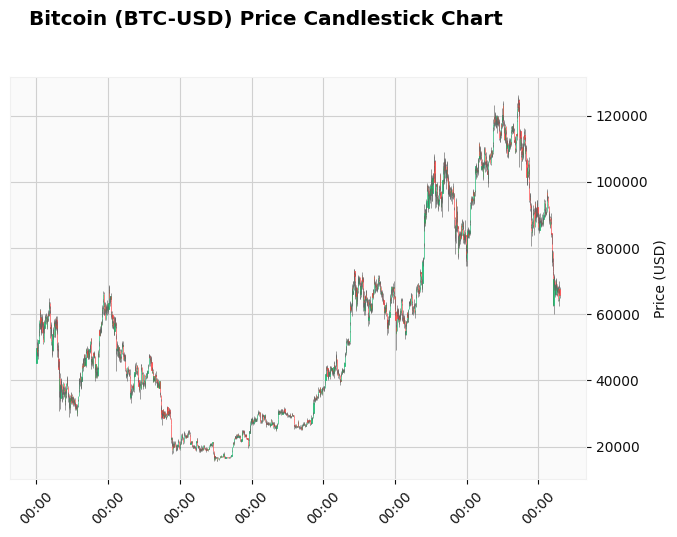

In [ ]:

import matplotlib.pyplot as plt

# Ensure the index is a DatetimeIndex for mplfinance
df.index = pd.to_datetime(df.index)

# Plot the candlestick chart
fig, ax = mpf.plot(
    df, # Use the 'df' DataFrame
    type='candle',
    style='yahoo',
    title='Bitcoin (BTC-USD) Price Candlestick Chart',
    ylabel='Price (USD)',
    figscale=1,
    returnfig=True
)

plt.show()

In [ ]:
# Check correltion
correlation = df.corr()
print(correlation["Close"]) # you can use ,sort_values() to sort the values in ascendind or descending order

Close     1.000000
High      0.999315
Low       0.999228
Open      0.998483
Volume    0.553196
Date      0.717194
Name: Close, dtype: float64


**Predicting the future prices of cryptocurrency is based on the problem of Time series analysis. The AutoTS library in Python is one of the best libraries for time series analysis.**

In [ ]:
!pip install autots

In [ ]:
from autots import AutoTS

In [ ]:
model = AutoTS(forecast_length=30, frequency='infer', ensemble='simple')

Using 1 cpus for n_jobs.


In [ ]:
model = model.fit(df, date_col='Date', value_col='Close', id_col=None)

Data frequency is: D, used frequency is: D
Model Number: 1 with model AverageValueNaive in generation 0 of 25
Model Number: 2 with model AverageValueNaive in generation 0 of 25
Model Number: 3 with model AverageValueNaive in generation 0 of 25
Model Number: 4 with model DatepartRegression in generation 0 of 25
Model Number: 5 with model ETS in generation 0 of 25
Model Number: 6 with model GLM in generation 0 of 25
Model Number: 7 with model GLS in generation 0 of 25
Model Number: 8 with model LastValueNaive in generation 0 of 25
Model Number: 9 with model LastValueNaive in generation 0 of 25
Model Number: 10 with model LastValueNaive in generation 0 of 25
Model Number: 11 with model SeasonalNaive in generation 0 of 25
Model Number: 12 with model SeasonalNaive in generation 0 of 25
Model Number: 13 with model VAR in generation 0 of 25
Template Eval Error: ValueError('Only gave one variable to VAR') in model 13 in generation 0: VAR
Model Number: 14 with model ConstantNaive in generation 

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.515e+11, tolerance: 7.671e+07
  model = cd_fast.enet_coordinate_descent(


Model Number: 47 with model GLM in generation 0 of 25
Template Eval Error: ValueError('regression_type=user and no future_regressor passed') in model 47 in generation 0: GLM
Model Number: 48 with model UnivariateMotif in generation 0 of 25
Model Number: 49 with model ARDL in generation 0 of 25
Template Eval Error: ValueError("regression_type='User' but future_regressor not supplied") in model 49 in generation 0: ARDL
Model Number: 50 with model ARCH in generation 0 of 25
Template Eval Error: ImportError('`arch` package must be installed from pip') in model 50 in generation 0: ARCH
Model Number: 51 with model ConstantNaive in generation 0 of 25
Model Number: 52 with model LastValueNaive in generation 0 of 25
Model Number: 53 with model AverageValueNaive in generation 0 of 25
Model Number: 54 with model GLS in generation 0 of 25
Model Number: 55 with model SeasonalNaive in generation 0 of 25
Model Number: 56 with model VAR in generation 0 of 25
Template Eval Error: ValueError('Only gave 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py

Model Number: 60 with model RRVAR in generation 0 of 25
Model Number: 61 with model MetricMotif in generation 0 of 25
Model Number: 62 with model Cassandra in generation 0 of 25
Template Eval Error: ValueError("regression_type=='User' but no future_regressor supplied") in model 62 in generation 0: Cassandra
Model Number: 63 with model SeasonalityMotif in generation 0 of 25
Model Number: 64 with model FFT in generation 0 of 25
Model Number: 65 with model BallTreeRegressionMotif in generation 0 of 25
Model Number: 66 with model BasicLinearModel in generation 0 of 25
Template Eval Error: ValueError("regression_type=='User' but no future_regressor supplied") in model 66 in generation 0: BasicLinearModel
Model Number: 67 with model DMD in generation 0 of 25
Model Number: 68 with model ARCH in generation 0 of 25
Template Eval Error: ImportError('`arch` package must be installed from pip') in model 68 in generation 0: ARCH
Model Number: 69 with model BasicLinearModel in generation 0 of 25
Mod

...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

57 - Ensemble with avg smape 6.02 in 6.92s: 
58 - Ensemble with avg smape 5.98 in 6.93s: 
59 - Ensemble with avg smape 6.62 in 6.95s: 
60 - Ensemble with avg smape 7.62 in 6.96s: 
61 - Ensemble with avg smape 14.8 in 6.97s: 
62 - Ensemble with avg smape 19.86 in 6.98s: 
Postprocessing Error: Exception("Transformer HistoricValues failed on fit from params fake_date {'0': {'rows': 1, 'lag': 1, 'method': 'additive', 'strength': 1.0, 'first_value_only': False, 'threshold': 10, 'threshold_method': 'mean'}, '1': {'window': 28}} with error KeyError('2')") in model 62 postprocessor 0: Ensemble
63 - Ensemble with avg smape 7.47 in 6.99s: 
64 - Ensemble with avg smape 6.02 in 7.00s: 
65 - Ensemble with avg smape 12.69 in 7.02s: 
66 - Ensemble with avg smape 14.31 in 7.03s: 
67 - Ensemble with avg smape 6.11 in 7.06s: 
68 - Ensemble with avg smape 8.94 in 7.07s: 
69 - Ensemble with avg smape 5.98 in 7.09s: 
70 - Ensemble with avg smape 6.21 in 7.11s: 
Model Number: 71 of 9 with model Ensemble for

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

85 - Ensemble with avg smape 5.85 in 5.88s: 
86 - Ensemble with avg smape 5.86 in 5.88s: 
87 - Ensemble with avg smape 5.88 in 5.90s: 
88 - Ensemble with avg smape 7.72 in 5.91s: 
89 - Ensemble with avg smape 14.83 in 5.92s: 
90 - Ensemble with avg smape 19.86 in 5.93s: 
Postprocessing Error: Exception("Transformer HistoricValues failed on fit from params fake_date {'0': {'rows': 1, 'lag': 1, 'method': 'additive', 'strength': 1.0, 'first_value_only': False, 'threshold': 10, 'threshold_method': 'mean'}, '1': {'window': 28}} with error KeyError('2')") in model 90 postprocessor 0: Ensemble
91 - Ensemble with avg smape 7.84 in 5.94s: 
92 - Ensemble with avg smape 5.85 in 5.95s: 
93 - Ensemble with avg smape 12.71 in 5.97s: 
94 - Ensemble with avg smape 14.66 in 5.98s: 
95 - Ensemble with avg smape 6.13 in 6.01s: 
96 - Ensemble with avg smape 8.77 in 6.03s: 
97 - Ensemble with avg smape 5.86 in 6.05s: 
98 - Ensemble with avg smape 6.24 in 6.07s: 
Model Number: 99 of 9 with model Ensemble fo

/usr/local/lib/python3.12/dist-packages/autots/evaluator/auto_model.py:3128: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  validation_results.model_results = validation_results.model_results.replace(
/usr/local/lib/python3.12/dist-packages/autots/evaluator/auto_model.py:3128: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  validation_results.model_results = validation_results.model_results.replace(


In [ ]:
prediction = model.predict()

In [ ]:
forecast = prediction.forecast

In [ ]:
print(forecast)

                   Close
2026-02-28  65881.796875
2026-03-01  68754.994806
2026-03-02  69401.279964
2026-03-03  69146.600880
2026-03-04  68882.212595
2026-03-05  68793.323868
2026-03-06  68668.040205
2026-03-07  67279.358139
2026-03-08  69124.023565
2026-03-09  70094.103391
2026-03-10  69626.651045
2026-03-11  68883.757506
2026-03-12  69002.038159
2026-03-13  69496.740902
2026-03-14  69622.446956
2026-03-15  70281.607352
2026-03-16  69981.632073
2026-03-17  70037.220701
2026-03-18  69086.724706
2026-03-19  68865.137608
2026-03-20  67526.127132
2026-03-21  66743.570754
2026-03-22  67017.614368
2026-03-23  66258.259282
2026-03-24  65647.177191
2026-03-25  66033.671475
2026-03-26  66006.840929
2026-03-27  65892.944584
2026-03-28  65958.869683
2026-03-29  65684.999178
